In [ ]:
#Jupyter Notebook config
%load_ext autoreload
%autoreload 2
%matplotlib widget

In [ ]:
#Load necessary python packages
import matplotlib.pyplot as plt
from matplotlib import colormaps
import seaborn as sns
import cartopy.crs as ccrs
from cmocean import cm
import numpy as np
import xarray as xr
import gsw
from skimage import measure
from scipy import interpolate
import shapely.geometry as geometry
from shapely import wkt
import pyproj

from ipywidgets import widgets
from IPython.display import display

#Import custom package for working with Beaufort Gyre data
import datatools.plots.maps as mapper
from datatools.DOT.DataServer import DataServer
from datatools.DOT import operations as satops

In [ ]:
#Load in Satellite Data
sat_data_server = DataServer("/Users/ben/Desktop/3D-TEA-BAG/data/CPOM_DOT.nc", "/Users/ben/Desktop/3D-TEA-BAG/data/Full_DOT_data_Arco_2025_09.nc")

#### Find and Plot the location of the Beaufort Gyre
The location of the Beaufot Gyre is plotted using the method described in Regan, et. al (2018). The location of the gyre is defined at the point of maximum DOT between 140˚E and 100˚W and 68-81.5˚N.

 the so-called "Beaufort Gyre Box" as defined in Proshutinsky et al., 2009 (with bounds 130-170˚W and 70.5-80.5˚N)

In [ ]:
max_DOT_ds = max_DOT_ds.assign(extent = xr.full_like(max_DOT_ds['DOT'], "", dtype=object))
percision = 2
step = 10**(-percision)

def get_closed_contour_around_point(data, level, point_x, point_y):
    #Find all contours at that level
    contours = measure.find_contours(data, level)
    #Check if any contours are closed
    if np.array(mask := [np.isclose(contour[0], contour[-1]).all() for contour in contours]).any():
        #Discard all open contours
        contours = [closed_contour for closed_contour, mask_entry in zip(contours, mask) if mask_entry]
        if (mask:= np.array([measure.points_in_poly(np.array([[point_x, point_y]]), contour)[0] for contour in contours])).any():
            #If there is a contour with the point in it
            closed_contour_around_point = [contour for contour, mask_entry in zip(contours, mask) if mask_entry][0]
            return np.array(closed_contour_around_point, dtype=np.int64)
        else:
            return None
    else:
        return None 
for era in max_DOT_ds['era']:
    for time in max_DOT_ds['time']:
        working_DOT_da = max_DOT_ds.sel(time = time, era = era)
        if ~np.isnan(working_DOT_da['DOT']):
            #If the current time/era combination is valid
            if era == 'old':
                working_bg_ds = old_bg_ds
            elif era == 'new':
                working_bg_ds = new_bg_ds

            data = working_bg_ds['DOT'].sel(time = time).values.copy()
            data = np.round(data, percision)
            working_height = np.nanmin(data)

            #Find the BG extent contour
            while working_height < working_DOT_da['DOT'].copy():
                #Work up from the min height to find the lowest closed contour that contains the max DOT point 

                #Get the location of the max DOT point in array coordinate space
                working_x_coord = working_DOT_da['x']
                working_y_coord = working_DOT_da['y']

                if (contour := get_closed_contour_around_point(data, working_height, working_x_coord, working_y_coord)) is not None:
                    #If there is a closed contour at the working_height around the max DOT point, break
                    break 
                else:
                    #If there is no closed contour at the working height, increase the working height
                    working_height += step


            contour = get_closed_contour_around_point(data, working_height, working_x_coord, working_y_coord)

            if era == 'old':
                lon_mesh, lat_mesh = np.meshgrid(working_bg_ds.sel(time = time)['lon'], working_bg_ds.sel(time = time)['lat'])
                interp_lat = interpolate.RegularGridInterpolator((np.arange(working_bg_ds.sel(time = time)['lat'].size), np.arange(working_bg_ds.sel(time = time)['lon'].size)), lat_mesh, method = 'linear')
                interp_lon = interpolate.RegularGridInterpolator((np.arange(working_bg_ds.sel(time = time)['lat'].size), np.arange(working_bg_ds.sel(time = time)['lon'].size)), lon_mesh, method = 'linear')
            elif era == 'new':
                interp_lat = interpolate.RegularGridInterpolator((working_bg_ds.sel(time = time)['x'].values, working_bg_ds.sel(time = time)['y'].values), working_bg_ds.sel(time = time)['lat'].values, method = 'linear')
                interp_lon = interpolate.RegularGridInterpolator((working_bg_ds.sel(time = time)['x'].values, working_bg_ds.sel(time = time)['y'].values), working_bg_ds.sel(time = time)['lon'].values, method = 'linear')

            closed_lat = interp_lat(contour)
            closed_lon = interp_lon(contour)
    
            max_DOT_ds['extent'].loc[{'time': time, 'era': era}] = geometry.Polygon(np.vstack((closed_lat, closed_lon)).T).wkt


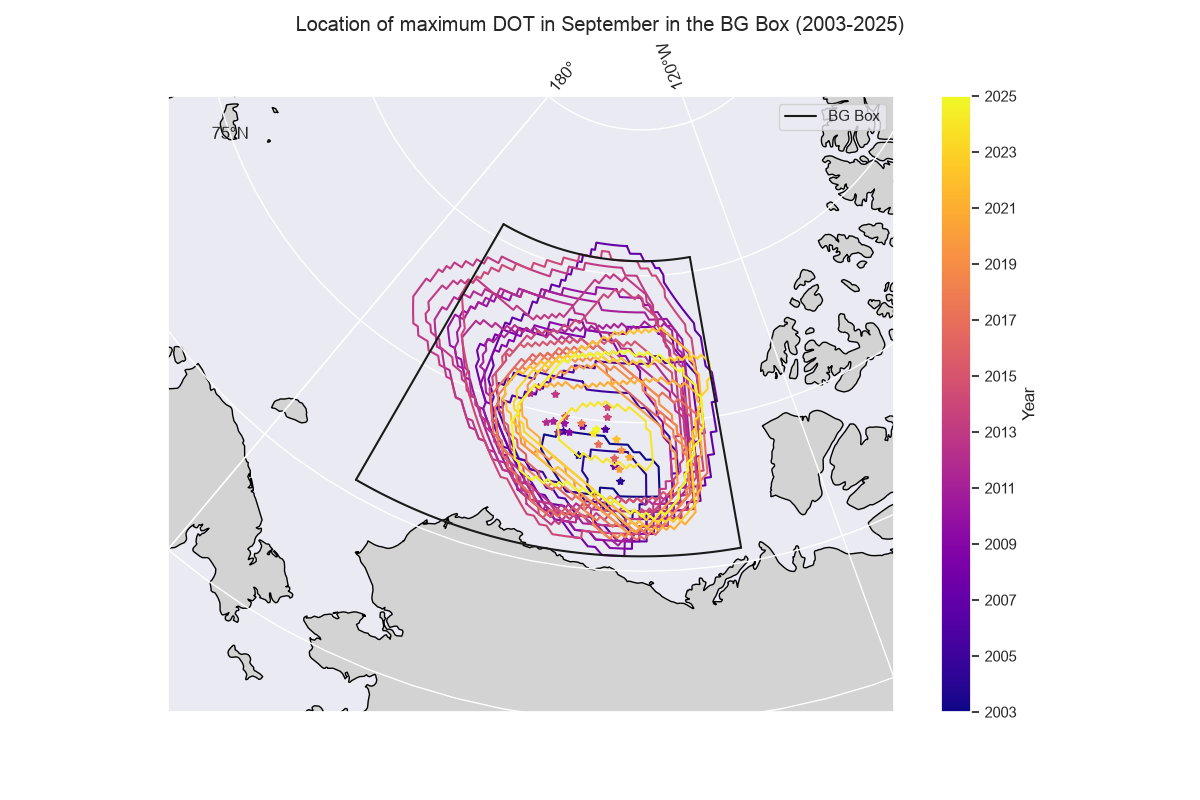

In [ ]:
#Plot location of max DOT and min DOT contour
extent = [-180, -120, 65, 85]

dot_figure = plt.figure(figsize=(12,8))
projection=ccrs.NorthPolarStereo(central_longitude=-140)
ax = mapper.setup_map(figure=dot_figure,
                      projection=projection,
                      extent=extent)

sns.set_theme()
    



years = np.arange(2003,2026)
colors = plt.cm.plasma(np.linspace(0, 1, len(years)))

for i, year in enumerate(years):
    working_data = max_DOT_ds.sel(time = np.datetime64(f'{year}-09-01'), era = 'old')
    if working_data['extent'].values != "":
        bg_extent = wkt.loads(working_data['extent'].values)
        points = 


        ax.plot(working_data['lon'], working_data['lat'], marker = '*', color = colors[i], transform = ccrs.PlateCarree())
            
        ax.plot(points[:,1], points[:,0], linestyle = '-', color = colors[i], transform = ccrs.PlateCarree())
    working_data = max_DOT_ds.sel(time = np.datetime64(f'{year}-09-01'), era = 'new')
    if working_data['extent'].values != "":
        bg_extent = wkt.loads(working_data['extent'].values)
        points = satops.polygon_to_array(bg_extent)


        ax.plot(working_data['lon'], working_data['lat'], marker = '*', color = colors[i], transform = ccrs.PlateCarree())
                    
        ax.plot(points[:,1], points[:,0], linestyle = '-', color = colors[i], transform = ccrs.PlateCarree())

sm = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(years.min(), years.max()))
sm.set_array([])
cbar = dot_figure.colorbar(sm, ax=ax)
cbar.set_label('Year')
tick_years = years[::2]  # every other year
cbar.set_ticks(tick_years)
cbar.set_ticklabels([str(y) for y in tick_years])
#Plot the Beaufort Gyre Box
top_bottom_lon= np.linspace(-170, -130, 100)
top_lat = np.full_like(top_bottom_lon, 80.5)
bottom_lat = np.full_like(top_bottom_lon, 70.5)
ax.plot([-170, -170], [70.5, 80.5], 'k-', transform = ccrs.PlateCarree(), label = 'BG Box')
ax.plot([-130, -130], [70.5, 80.5], 'k-', transform = ccrs.PlateCarree())
ax.plot(top_bottom_lon, top_lat, 'k-', transform = ccrs.PlateCarree())
ax.plot(top_bottom_lon, bottom_lat, 'k-', transform = ccrs.PlateCarree())

ax.legend()

dot_figure.suptitle("Location of maximum DOT in September in the BG Box (2003-2025)")


plt.show()

In [ ]:
#Calculate the area of the Beaufort Gyre
project = pyproj.Transformer.from_crs(
    "EPSG:4326",   # WGS84 lat/lon
    "ESRI:102003", # USA Contiguous Albers Equal Area (use a regional one if not in US)
    always_xy=True
).transform